# Extract NDVI from Analytic Imagery

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from exactextract import exact_extract
# import exactextract
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box

import rasterio
import rasterio.merge
import glob

import warnings

from matplotlib.collections import PolyCollection

sys.path.append("../utils")

nov_data_root = os.path.join(
    "/"
    "data",
    "wildfire_prep",
    "full_planet",
    "unzipped",
    "2020",
    "nov", 
    "files"
)

capstone_data_root = "/capstone/wildfire_prep/data"

import config

### Create filepath lists by month per year

In [2]:
fp = "/data/wildfire_prep/full_planet/unzipped"

month_sea = ["month_12", "month_11", "month_10", "month_09", "month_08", "month_07", "month_06", "month_05", "month_04", "month_03", "month_02", "month_01"]
month_name = ["dec", "nov", "oct", "sep", "aug", "jul", "jun", "may", "apr", "mar", "feb", "jan"]
year_sea = ["2019", "2020", "2021", "2022", "2023"]

for year in year_sea:
    for month in month_name: 
        init_list = []
        for root,dirs,files in os.walk(fp, topdown=True):
            for file in files:
                if "AnalyticMS_SR_clip_bandmath" in file and f'{year}/' in root and f'{month}/' in root and "reprojected" not in root:
                    init_list.append(f"{root}/{file}")
                    globals()[f"filepaths_{year}_{month}"] = init_list

In [5]:
month_sea = ["month_12", "month_11", "month_10", "month_09", "month_08", "month_07", "month_06", "month_05", "month_04", "month_03", "month_02", "month_01"]
month_name = ["dec", "nov", "oct", "sep", "aug", "jul", "jun", "may", "apr", "mar", "feb", "jan"]
year_sea = ["2019", "2020", "2021", "2022", "2023"]

### Import buffer geometries

In [ ]:
# Import joined inspections and buildings
def import_buffer_geometries(year, kind = "training"):
    """
    Function to read in buffer geometry data for a given year and convert to Albers CRS.
    """

    if (kind == "training") | (kind == "buffer"):
        next
    else:
        print("give kind argument either 'training', or 'buffer'")
        return None


    buffer_geometries = os.path.join(
        capstone_data_root,
        f"{kind}_geometries",
        f"{kind}_geometries_{year}.geojson",
    )

    buffer_geometries = gpd.read_file(buffer_geometries).to_crs(
        "EPSG:3310"
    )
    return buffer_geometries


# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
training_geometries_dict = {}
for year in range(2019, 2024):
    training_geometries_dict[year] = import_buffer_geometries(year)

In [248]:
# Unpack from dictionary
training_geometries_2019 = buffer_geometries_dict[2019]
training_geometries_2020 = buffer_geometries_dict[2020]
training_geometries_2021 = buffer_geometries_dict[2021]
training_geometries_2022 = buffer_geometries_dict[2022]
training_geometries_2023 = buffer_geometries_dict[2023]

In [45]:
test_buffer_geoms = import_buffer_geometries(2019, "buffer")
test_buffer_geoms

,fulcrum_id,created_at,updated_at,system_cre,system_upd,version,status,project,assigned_t,latitude,...,numberfield2,previousyrinspecteddata,previousyrinspectionstatus,calculatededitor,calculatededitdate,creationdate,inspection_id,month,apn,geometry
0,d9a4d031-d16d-4c84-b32c-f3fcd7d945df,2018-05-25 16:25:06,2019-06-05 11:57:49,2019-05-07 11:52:36,2019-06-05 16:35:26,2.0,Compliant,None,None,34.669616,...,None,None,None,None,None,None,1,6,141-010-040,"POLYGON ((-2813.179 -371821.557, -2813.179 -37..."
1,7f9b6d98-548d-4b94-97c6-82cbddf84d99,2018-05-25 16:25:10,2019-05-15 12:26:44,2019-05-07 11:52:37,2019-05-15 12:26:45,3.0,Compliant,None,None,34.679129,...,None,None,None,None,None,None,2,5,135-310-022,"POLYGON ((-8368.416 -370860.259, -8475.394 -37..."
2,03afdf39-173a-4f02-bfdc-e0725e554959,2018-05-25 16:25:11,2019-05-09 14:20:04,2019-05-07 11:52:37,2019-05-09 15:26:24,2.0,Compliant,None,None,34.676197,...,None,None,None,None,None,None,3,5,135-310-075,"POLYGON ((-8253.618 -371073.707, -8136.129 -37..."
3,941e29b0-6cd3-4c7e-a919-b8f2410b4a2b,2018-05-25 16:25:11,2019-05-09 14:25:18,2019-05-07 11:52:38,2019-05-09 15:26:26,2.0,Compliant,None,None,34.677982,...,None,None,None,None,None,None,4,5,135-310-075,"POLYGON ((-8201.866 -370989.432, -8201.866 -37..."
4,abe890ba-3269-4ef6-84d7-4a9b6bfd717e,2018-05-25 16:25:11,2019-12-17 14:16:14,2019-05-07 11:52:38,2019-12-18 11:43:23,5.0,Compliant,None,None,34.678469,...,None,None,None,None,None,None,5,12,135-310-042,"POLYGON ((-7966.144 -370818.558, -7966.144 -37..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14670,06ef334f-09c2-4384-aeba-8d32c72f099a,2019-08-26 13:08:40,2019-09-26 07:36:44,2019-08-26 16:26:42,2019-09-26 07:36:44,4.0,Compliant,None,None,34.665221,...,None,None,None,None,None,None,13073,8,None,"POLYGON ((-11247.563 -372381.807, -11174.015 -..."
14671,f87ac8af-2613-46ef-9f40-9fe39d238eca,2019-12-02 10:46:45,2019-12-03 16:52:14,2019-12-02 10:47:49,2019-12-03 16:52:14,3.0,Compliant,None,None,34.457385,...,None,None,None,None,None,None,13939,12,None,"POLYGON ((25871.372 -395420.787, 25950.115 -39..."
14672,7272220d-524b-4ab1-b66f-b7d967da26b7,2018-06-18 14:14:37,2019-11-07 08:06:10,2019-05-28 15:31:16,2019-11-07 08:06:10,3.0,Compliant,None,None,34.493258,...,None,None,None,None,None,None,4351,11,None,"POLYGON ((18469.942 -391458.28, 18547.758 -391..."
14673,020a03ba-ed27-4a54-8c48-28c427802f3d,2019-06-29 15:52:38,2019-08-01 15:49:22,2019-06-29 15:57:23,2019-08-01 15:49:22,5.0,Compliant,None,None,35.042135,...,None,None,None,None,None,None,12582,6,None,"POLYGON ((9685.178 -330543.121, 9762.994 -3305..."


### Make function

In [5]:
def make_ndvi_tifs(fp_list, year, month): 

    ndvi_path_root = "/data/wildfire_prep/ndvi"
    orig_crs = 'wgs84'
    # reproj_crs = 'albers'

    full_dir = f'{ndvi_path_root}/{year}/{month}'
    
    # target_crs = "EPSG:3310"
    # albers_file_nm = f"ndvi_reproj_{i}.tif" 
    # albers_path = f'{full_dir}/{reproj_crs}/{albers_file_nm}'
    
    
    i = 0

    for fp in fp_list:
        

        # make file paths and related vars
        wgs_file_nm = f"ndvi_{i}.tif" 
        wgs_path = f'{full_dir}/{orig_crs}/{wgs_file_nm}'

        # check if wgs filepath exists, make it if it doesn't
        if not os.path.exists(f'{full_dir}/{orig_crs}'):
            os.makedirs(f'{full_dir}/{orig_crs}')



        # Open image file
        # Load red and NIR bands - note all PlanetScope 4-band images have band order BGRN
        with rasterio.open(fp) as src:
            band_red = src.read(3)

        with rasterio.open(fp) as src:
            band_nir = src.read(4)
        


        # Allow division by zero
        np.seterr(divide='ignore', invalid='ignore')

        # Calculate NDVI
        ndvi = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)




        # Set spatial characteristics of the output object to mirror the input
        kwargs = src.meta
        kwargs.update(
            dtype=rasterio.float32,
            count = 1)

        # Create the file
        with rasterio.open(wgs_path, 'w', **kwargs) as dst:
            dst.write_band(1, ndvi.astype(rasterio.float32))
        

        # increment i for the filenames
        i += 1

In [6]:
def reproject_ndvi(ndvi_fp_list, year, month):
    
    # declare vars
    j = 0

    orig_crs = 'wgs84'

    ndvi_path_root = "/data/wildfire_prep/ndvi"
    reproj_crs = 'albers'
    target_crs = "EPSG:3310"

    full_dir = f'{ndvi_path_root}/{year}/{month}'

    # make fp for albers
    if not os.path.exists(f'{full_dir}/{reproj_crs}'):
        os.makedirs(f'{full_dir}/{reproj_crs}')


    for fp in ndvi_fp_list:

        wgs_file_nm = f"ndvi_{j}.tif" 
        wgs_path = f'{full_dir}/{orig_crs}/{wgs_file_nm}'

        albers_file_nm = f"ndvi_reproj_{j}.tif"     
        albers_path = f'{full_dir}/{reproj_crs}/{albers_file_nm}'

        # Open the source dataset
        with rasterio.open(wgs_path) as src:
            # Calculate the transformation parameters for reprojection
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds)
            
            # Update the metadata for the output file
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': target_crs,
                'transform': transform,
                'width': width,
                'height': height
            })
            
            # Create the output file with the updated metadata
            with rasterio.open(albers_path, 'w', **kwargs) as dst:
                # Reproject each band
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs,
                        resampling=Resampling.nearest)
                    
        j += 1

In [343]:
for year in year_sea:
    for month in month_name: 
        print(f" path for {year}_{month}: {globals()[f'filepaths_{year}_{month}']}")

        make_ndvi_tifs(globals()[f'filepaths_{year}_{month}'], year, month)

 path for 2019_dec: ['/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191202_165715_1_1049_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191227_181222_0e19_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191205_165628_0f2a_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191219_182603_1032_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191216_182101_101f_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191206_182547_0f34_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191220_184204_39_106b_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/files/20191219_165724_0f3c_3B_AnalyticMS_SR_clip_bandmath.tif', '/data/wildfire_prep/full_planet/unzipped/2019/dec/fil

In [355]:
ndvi_fp = '/data/wildfire_prep/ndvi'
init_list = []

In [ ]:

for year in year_sea:
    for month in month_name: 
        init_list = []
        ndvi_fp = f'/data/wildfire_prep/ndvi/{year}/{month}/wgs84'
        for root,dirs,files in os.walk(ndvi_fp, topdown=True):
            # print([sorted(int(file[5:-4]) for file in files)])
            for file in files: 
                init_list.append(f"{root}/{file}")
                globals()[f"ndvi_filepaths_{year}_{month}"] = init_list

In [359]:
for year in year_sea:
    for month in month_name: 
        print(f" path for {year}_{month}: {globals()[f'ndvi_filepaths_{year}_{month}']}")

        reproject_ndvi(globals()[f'ndvi_filepaths_{year}_{month}'], year, month)

 path for 2019_dec: ['/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_123.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_31.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_165.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_204.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_7.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_9.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_219.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_152.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_82.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_29.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_206.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_0.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_87.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_79.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_228.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_51.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs84/ndvi_120.tif', '/data/wildfire_prep/ndvi/2019/dec/wgs8

In [ ]:
# albers_fp = '/data/wildfire_prep/ndvi/2019/dec/albers'
# output = '/data/wildfire_prep/ndvi/2019/dec/mosaic'
# mosaic_fp = f"{output}/test_mosaic.tif"

In [363]:
init_list = []

for year in year_sea:
    for month in month_name: 
        init_list = []
        albers_fp = f'/data/wildfire_prep/ndvi/{year}/{month}/albers'
        for root,dirs,files in os.walk(albers_fp, topdown=True):
            for file in files: 
                init_list.append(f"{root}/{file}")
                globals()[f"reproj_ndvi_filepaths_{year}_{month}"] = init_list



In [73]:
reproj_ndvi_filepaths_2019_dec

['/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_157.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_45.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_15.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_27.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_134.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_68.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_85.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_183.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_105.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_174.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_58.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_17.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_233.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_33.tif',
 '/data/wildfire_prep/ndvi/2019/dec/albers/ndvi_reproj_133.tif',
 '/data/wildfire_prep/ndvi/2019/d

In [ ]:
# mosaic writing, deprecated


# # Find all .tif files in the directory
# tif_files = glob.glob(f"{albers_fp}/*.tif")

# # Open the rasters
# rasters = [rasterio.open(f) for f in tif_files]

# # Merge the rasters into a single mosaic
# mosaic, transform = rasterio.merge.merge(rasters, method = "max")

# # Define output metadata
# out_meta = rasters[0].meta.copy()
# out_meta.update({
#     "driver": "GTiff",
#     "height": mosaic.shape[1],
#     "width": mosaic.shape[2],
#     "transform": transform
# })

# # make all 0 vals na


# # Write the merged mosaic to disk
# with rasterio.open(mosaic_fp, "w", **out_meta) as dest:
#     dest.write(mosaic)

# # Close the rasters
# for raster in rasters:
#     raster.close()


In [ ]:
# all_buffers = gpd.GeoDataFrame(columns = ['fulcrum_id', 'geometry'])
# intersect_count = 0

# full_ndvi_stats = gpd.GeoDataFrame(columns = ['fulcrum_id', 'mean', 'min', 'max'])

# for fp in reproj_ndvi_filepaths_2019_dec:

#     # First, open the NDVI raster to get its extent
#     with rasterio.open(fp) as src:
#         # Get the bounds of the raster
#         raster_bounds = src.bounds
#         # Create a polygon from the bounds
#         raster_geometry = box(raster_bounds.left, raster_bounds.bottom, 
#                             raster_bounds.right, raster_bounds.top)
#         # Create a GeoDataFrame from the raster extent
#         raster_extent = gpd.GeoDataFrame({'geometry': [raster_geometry]}, crs=src.crs)
        
#         # Check if we need to reproject the extent
#         if test_buffer_geoms.crs != src.crs:
#             raster_extent = raster_extent.to_crs(test_buffer_geoms.crs)


#         # then get rid of records with no fulcrum id
#         test_buffer_geoms = test_buffer_geoms[test_buffer_geoms['fulcrum_id'].notnull()]




#         # Filter buffer geometries to only those that intersect with the raster extent
#     intersecting_buffers = test_buffer_geoms[
#         test_buffer_geoms.intersects(raster_extent.iloc[0].geometry)
#     ]

#     # all_buffers = pd.concat([all_buffers, intersecting_buffers])


#     # Extract NDVI values only for the intersecting geometries
#     # First ensure the CRS match
#     if intersecting_buffers.crs != src.crs:
#         intersecting_buffers = intersecting_buffers.to_crs(src.crs)

#     # intersecting_buffers['inspection_id'] = intersecting_buffers['inspection_id'].astype(str)
    

#     # Use exactextract to calculate statistics for each geometry
#     ndvi_stats = exact_extract(
#         fp,
#         intersecting_buffers,
#         ['mean', 'min', 'max'],
#         include_cols=['inspection_id'], 
#         output="pandas",
#     )

#     full_ndvi_stats = pd.concat([full_ndvi_stats, ndvi_stats])
#     full_ndvi_stats = full_ndvi_stats[full_ndvi_stats['max'] != 0].dropna(subset=['max']).groupby('fulcrum_id').mean().reset_index()
    

#     intersect_count = intersect_count + len(intersecting_buffers)
#     print(f"Found {len(intersecting_buffers)} geometries that intersect with the NDVI raster")
# print("------------------------------")

# print(f"target length: {len(buffer_geometries_2019)}")
# print(f"total intersection polygons: {intersect_count}")


/tmp/ipykernel_738988/364240353.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_ndvi_stats = pd.concat([full_ndvi_stats, ndvi_stats])


Found 1 geometries that intersect with the NDVI raster
Found 2 geometries that intersect with the NDVI raster
Found 99 geometries that intersect with the NDVI raster
Found 104 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 3 geometries that intersect with the NDVI raster
Found 59 geometries that intersect with the NDVI raster
Found 18 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 4 geometries that intersect with the NDVI raster
Found 104 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 1 geometries that intersect with the NDVI raster
Found 346 geometries that intersect with the NDVI raster
Found 104 geometries that intersect with the NDVI raster

In [223]:
full_ndvi_stats[full_ndvi_stats['max'] != 0]['fulcrum_id'].value_counts()

fulcrum_id
387d9e3f-eeb6-41a4-92d1-0773ca2add64    16
ddb20a42-faea-4aad-ada8-f9ad972f988c    16
a6a0469f-cfa5-44c6-a335-dc91dea95069    15
671816e1-bcac-45a9-9fd6-ff09f42948d9    15
51268bbc-e3b7-4854-b0cf-98fbf9e3da9e    15
                                        ..
3c10fbd3-54d2-475e-9244-9b609938feab     1
8ae94be3-8b8c-46a7-aa1b-5cf6726df6d5     1
d7617b7a-d2d4-4d82-9a0c-51829a6904e5     1
62cdeda0-77fc-41f4-8cd3-6a966be4a2b0     1
44bdb785-2628-461d-a9f9-2864cc10ef1b     1
Name: count, Length: 4008, dtype: int64

In [244]:
full_ndvi_stats[full_ndvi_stats['max'] != 0].dropna(subset=['max']).groupby('fulcrum_id').mean().reset_index()



,fulcrum_id,mean,min,max
0,0023c48a-bf96-435c-a652-4a13228a2b60,0.198644,0.064161,0.501018
1,0045ebea-b892-46e2-9d76-2925a7854017,0.436099,0.071977,0.663488
2,0090616a-b88c-4286-bcc1-16c29de43d40,0.339549,-0.055548,0.573614
3,009b2262-87d6-453f-9f5b-667b6dbfa518,0.351085,0.208921,0.536279
4,00ae7bb8-add5-4313-8746-6b9f39208876,0.340196,0.118605,0.604094
...,...,...,...,...
1291,ff9ec95e-32b5-4c71-9250-f297388540c1,0.375984,0.121947,0.602447
1292,ffb6bf72-7d2d-45f3-bb3f-d282e3054df5,0.151141,0.073750,0.260079
1293,ffc183bd-cfec-41f7-b03b-7edea407b720,0.182109,0.089690,0.243645
1294,ffdb7f8c-f6b5-4fee-a769-f6e6389579de,0.494253,0.256078,0.589773


In [ ]:
[name for name in list(globals().keys()) if globals().keys().__contains__('reproj_ndvi_filepaths_2022_dec') is True]

['__name__',
 '__doc__',
 '__package__',
 '__loader__',
 '__spec__',
 '__builtin__',
 '__builtins__',
 '_ih',
 '_oh',
 '_dh',
 'In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'open',
 '_',
 '__',
 '___',
 '__vsc_ipynb_file__',
 '_i',
 '_ii',
 '_iii',
 '_i1',
 'os',
 'sys',
 'np',
 'pd',
 'gpd',
 'plt',
 'mpatches',
 'sns',
 'exact_extract',
 'calculate_default_transform',
 'reproject',
 'Resampling',
 'box',
 'rasterio',
 'glob',
 'nov_data_root',
 'capstone_data_root',
 'config',
 '_i2',
 'fp',
 'month_sea',
 'month_name',
 'year_sea',
 'year',
 'month',
 'init_list',
 'root',
 'dirs',
 'files',
 'file',
 'filepaths_2019_dec',
 'filepaths_2019_nov',
 'filepaths_2019_oct',
 'filepaths_2019_sep',
 'filepaths_2019_aug',
 'filepaths_2019_jul',
 'filepaths_2019_jun',
 'filepaths_2019_may',
 'filepaths_2019_apr',
 'filepaths_2019_mar',
 'filepaths_2019_feb',
 'filepaths_2019_jan',
 'filepaths_2020_dec',
 'filepaths_2020_nov',
 'filepaths_2020_oct',
 'filepaths_2020_sep',
 'filepaths_2020_a

In [400]:
[name for name in list(globals().items()) if name.keys() == 'reproj_ndvi_filepaths_2022_dec']

AttributeError: 'tuple' object has no attribute 'keys'

In [416]:
def get_ndvi_value(reproj_fps_lst, geometries, join_id = 'inspection_id'):
    
    intersect_count = 0
    warning_counter = 0
    h = 0
    full_ndvi_stats = gpd.GeoDataFrame(columns = [join_id, 'mean', 'min', 'max'])

    # print("________number of geometries that interact with the rasters_________")
    # print(f"________statistics for _________")

    for fp in reproj_fps_lst:

        # First, open the NDVI raster to get its extent
        with rasterio.open(fp) as src:
            # Get the bounds of the raster
            raster_bounds = src.bounds
            # Create a polygon from the bounds
            raster_geometry = box(raster_bounds.left, raster_bounds.bottom, 
                                raster_bounds.right, raster_bounds.top)
            # Create a GeoDataFrame from the raster extent
            raster_extent = gpd.GeoDataFrame({'geometry': [raster_geometry]}, crs=src.crs)
            
            # Check if we need to reproject the extent
            if test_buffer_geoms.crs != src.crs:
                raster_extent = raster_extent.to_crs(test_buffer_geoms.crs)


            # then get rid of records with no fulcrum id
            geometries = geometries[geometries[join_id].notnull()]




            # Filter buffer geometries to only those that intersect with the raster extent
        intersecting_buffers = geometries[
            geometries.intersects(raster_extent.iloc[0].geometry)
        ]


        # Extract NDVI values only for the intersecting geometries
        # First ensure the CRS match
        if intersecting_buffers.crs != src.crs:
            intersecting_buffers = intersecting_buffers.to_crs(src.crs)

        

        # Use exactextract to calculate statistics for each geometry
        ndvi_stats = exact_extract(
            fp,
            intersecting_buffers,
            ['mean', 'min', 'max'],
            include_cols=[join_id], 
            output="pandas",
        )

        def custom_warning_handler(message, category, filename, lineno, file=None, line=None):
            global warning_counter
            warning_counter += 1

        warnings.simplefilter("always")
        warnings.showwarning = custom_warning_handler

        full_ndvi_stats = pd.concat([full_ndvi_stats, ndvi_stats])

        def aggregator(by, stats = full_ndvi_stats):

            aggregated = (
            stats[
                  (stats['mean'] != 0) & 
                  (stats['min'] != 0) & 
                  (stats['max'] != 0)
                ]
            [[join_id, by]]
                .dropna(subset=[by])
                .groupby(join_id)
                .agg(by)
                .reset_index()
                )
            
            return aggregated
            
        full_ndvi_stats_mean = aggregator("mean")
        full_ndvi_stats_min = aggregator("min")
        full_ndvi_stats_max = aggregator("max")

        # complete_ndvi_stats = full_ndvi_stats_mean.join(full_ndvi_stats_min, on = join_id, how = 'inner', lsuffix = '', rsuffix = '').join(full_ndvi_stats_max, on = join_id, how = 'inner',  lsuffix = '', rsuffix = '')
        complete_ndvi_stats = full_ndvi_stats_mean.merge(full_ndvi_stats_min, how = 'inner').merge(full_ndvi_stats_max, how = 'inner')

        intersect_count = intersect_count + len(intersecting_buffers)
        # print(f"raster {h}: {len(intersecting_buffers)}")
        h += 1

    print("------------------------------\n")

    # list_name = [name for name in list(globals().keys()) if name == 'reproj_ndvi_filepaths_2022_dec'][0]

    print(f"length of original geometries: {len(geometries)}")
    print(f"total intersection polygons: {intersect_count}")
    print(f'length of end dataset for this month/year: {len(complete_ndvi_stats)}')
    print(f'number of FutureWarnings triggered: {warning_counter}')

    return complete_ndvi_stats


In [372]:
test

,inspection_id,mean,min,max,ndvi_year,ndvi_month
0,53,0.419360,0.099194,0.841039,2019,dec
1,55,0.454005,-0.093549,0.823158,2019,dec
2,57,0.373048,-0.146466,0.810499,2019,dec
3,58,0.451366,0.128701,0.809023,2019,dec
4,59,0.512709,0.105865,0.859888,2019,dec
...,...,...,...,...,...,...
1375,14251,0.516632,0.348786,0.693869,2019,dec
1376,14252,0.564387,0.431467,0.688019,2019,dec
1377,14253,0.522473,0.310789,0.698726,2019,dec
1378,14254,0.539475,0.310789,0.688019,2019,dec


In [382]:
template_df

,inspection_id,mean,min,max,ndvi_year,ndvi_month
0,53,0.419360,0.099194,0.841039,2019,dec
1,55,0.454005,-0.093549,0.823158,2019,dec
2,57,0.373048,-0.146466,0.810499,2019,dec
3,58,0.451366,0.128701,0.809023,2019,dec
4,59,0.512709,0.105865,0.859888,2019,dec
...,...,...,...,...,...,...
1743,14628,0.433387,0.138185,0.740762,2019,oct
1744,14629,0.418580,0.138185,0.732202,2019,oct
1745,14630,0.461623,0.156691,0.732202,2019,oct
1746,14631,0.488482,0.230834,0.721191,2019,oct


In [384]:
template_df.to_csv('/data/wildfire_prep/tests/ndvi_parcels.csv')

In [417]:
template_df = pd.DataFrame(columns=['inspection_id', 'mean', 'min', 'max', 'ndvi_year', 'ndvi_month'])

for foo, sans in zip([reproj_ndvi_filepaths_2019_dec, 
            reproj_ndvi_filepaths_2019_nov, 
            reproj_ndvi_filepaths_2019_oct], 
            ['dec', 'nov', 'oct']
            ): 
    
    
    test = get_ndvi_value(foo, training_geometries_2019).assign(ndvi_year = 2019).assign(ndvi_month = sans)
    template_df = pd.concat([template_df, test])

template_df.to_csv('/data/wildfire_prep/tests/ndvi_parcels.csv')


------------------------------

length of original geometries: 14675
total intersection polygons: 16822
length of end dataset for this month/year: 1380
number of FutureWarnings triggered: 0


KeyboardInterrupt: 

In [418]:
template_df = pd.DataFrame(columns=['inspection_id', 'mean', 'min', 'max', 'ndvi_year', 'ndvi_month'])


for year in year_sea:
    for month in month_name:
        print(f'iteration for {year}/{month}')
        test = get_ndvi_value(globals()[f'reproj_ndvi_filepaths_{year}_{month}'], globals()[f'training_geometries_{year}']).assign(ndvi_year = year).assign(ndvi_month = month)
        template_df = pd.concat([template_df, test])

template_df.to_csv('/capstone/wildfire_prep/data/ndvi_csv/ndvi_parcels.csv')

iteration for 2019/dec
------------------------------

length of original geometries: 14675
total intersection polygons: 16822
length of end dataset for this month/year: 1380
number of FutureWarnings triggered: 0
iteration for 2019/nov
------------------------------

length of original geometries: 14675
total intersection polygons: 110836
length of end dataset for this month/year: 1089
number of FutureWarnings triggered: 0
iteration for 2019/oct
------------------------------

length of original geometries: 14675
total intersection polygons: 207212
length of end dataset for this month/year: 1748
number of FutureWarnings triggered: 0
iteration for 2019/sep
------------------------------

length of original geometries: 14675
total intersection polygons: 108665
length of end dataset for this month/year: 1290
number of FutureWarnings triggered: 0
iteration for 2019/aug
------------------------------

length of original geometries: 14675
total intersection polygons: 73385
length of end data

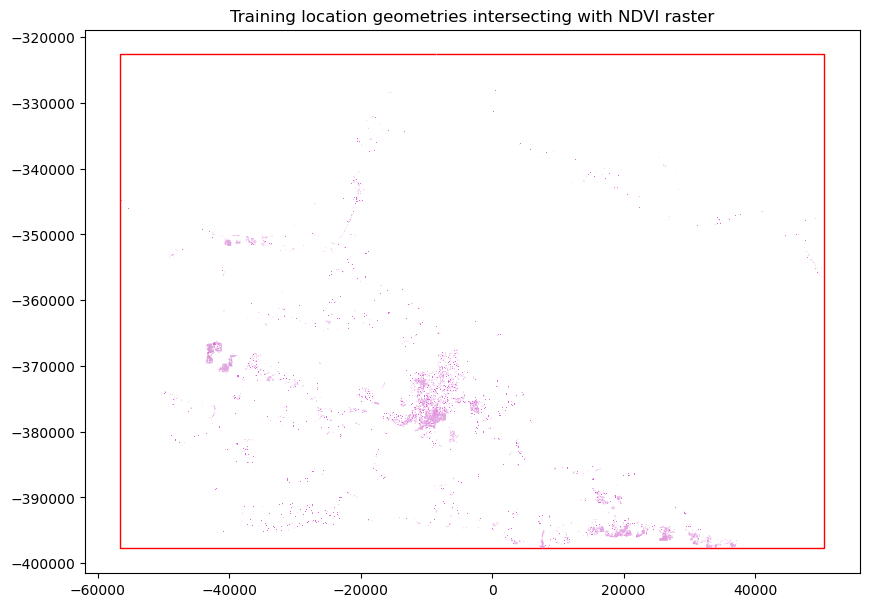

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 10))
# raster_extent.plot(ax=ax, color='none', edgecolor='red', linewidth=1)
# intersecting_buffers.plot(ax=ax, color='orchid')
# plt.title("Training location geometries intersecting with NDVI raster")
# plt.show()

In [ ]:
# # Extract NDVI values only for the intersecting geometries
# # First ensure the CRS match
# if intersecting_buffers.crs != src.crs:
#     intersecting_buffers = intersecting_buffers.to_crs(src.crs)

# intersecting_buffers['fulcrum_id'] = intersecting_buffers['fulcrum_id'].astype(str)

# # Use exactextract to calculate statistics for each geometry
# ndvi_stats = exact_extract(
#     mosaic_fp,
#     intersecting_buffers,
#     ['mean', 'min', 'max'],
#     include_cols=['fulcrum_id'], 
#     output="pandas",
# )

# # make all 0 vals na
# # ndvi_stats[ndvi_stats["max"] == 0] = np.nan

/Users/jpcohen/.conda/envs/wildfire_prep/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
# ndvi_stats[(ndvi_stats["max"] != 0) & (np.isnan(ndvi_stats["max"]) == np.False_)]

,fulcrum_id,mean,min,max
237,5d9a29c8-7d85-4a5f-a810-cd2b0b59614e,0.403546,0.000000,0.686619
238,b768d22f-77e8-44dd-b244-f40baef33bfa,0.039168,0.000000,0.556691
463,91e17cc1-d0b9-44d7-8294-f46b8e34f5dc,0.179479,-0.034027,0.359510
464,2cf1ef4f-82a2-44ab-9ee6-0b832f16190f,0.219409,-0.034027,0.378641
465,f9ea575d-3a31-4697-af01-83be52d30cf5,0.260409,0.101648,0.476581
...,...,...,...,...
13824,45e6fe44-4e25-4d42-b945-c4606a9baca6,0.322447,-0.007984,0.667793
13907,0e778054-68f9-4531-be9f-2db49ef8b1de,0.454746,0.340146,0.560927
13915,369eeaf0-6701-4e40-957e-1dadd52a19bc,0.631895,0.426731,0.766667
13989,None,0.556111,0.253651,0.784060


/tmp/ipykernel_738988/2831427568.py:53: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mean_patch = mpatches.Patch(color='none', edgecolor='white', label='Property Buffer Zone')


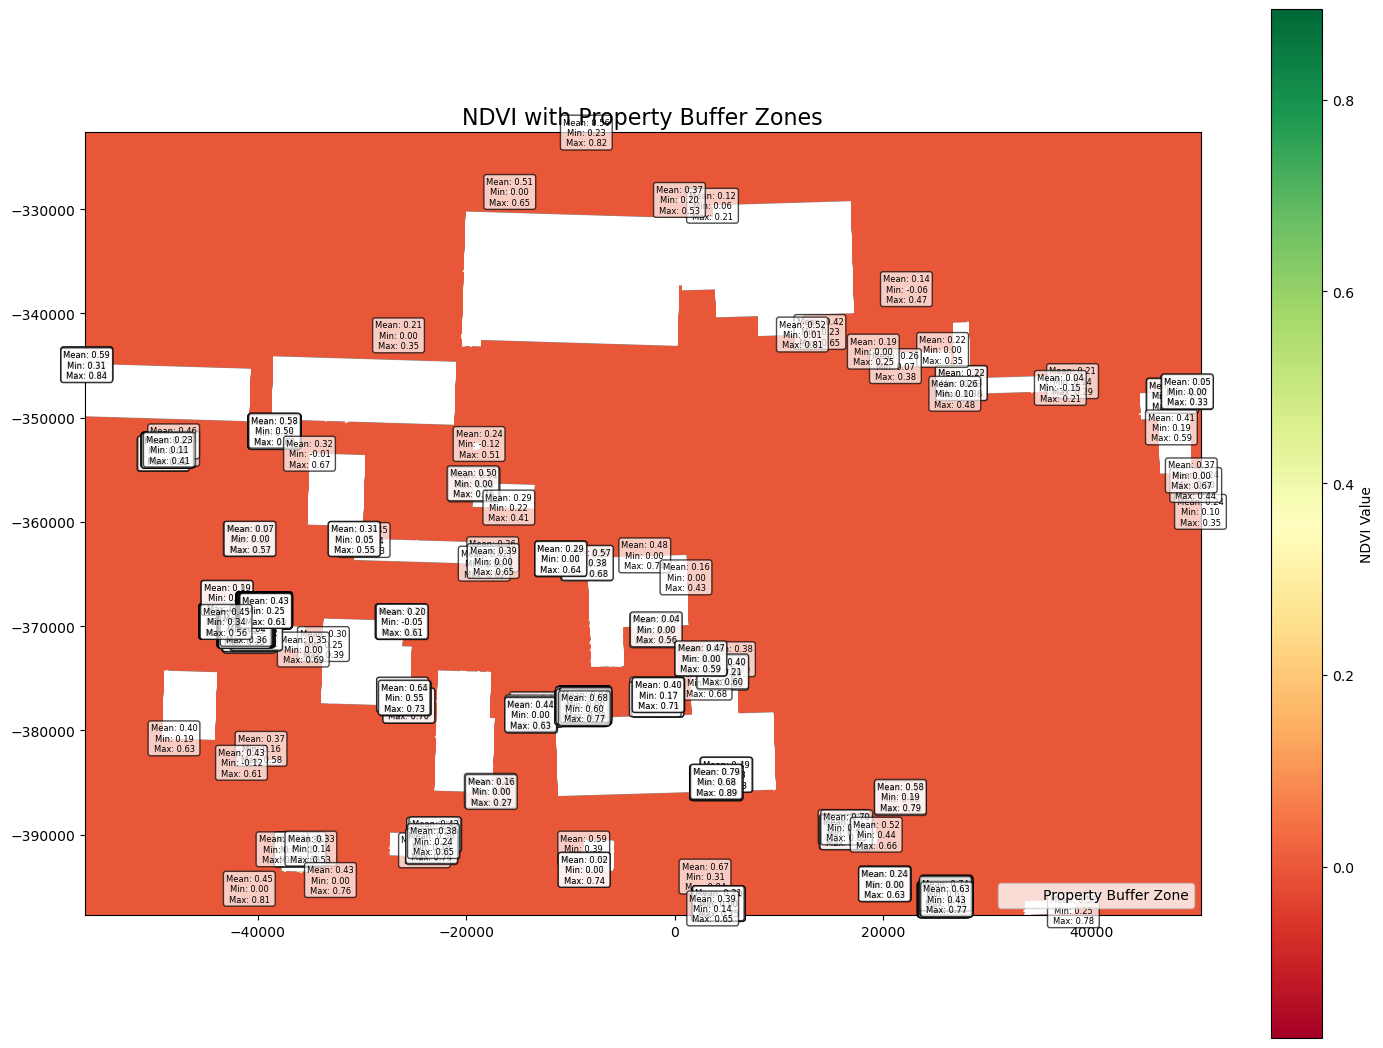

In [ ]:
# # Open the NDVI raster
# with rasterio.open(mosaic_fp) as src:
#     ndvi = src.read(1)
#     transform = src.transform
    
#     # Create a figure and axis
#     fig, ax = plt.subplots(figsize=(15, 15))
    
#     # Define a colormap for NDVI (false color)
#     ndvi_cmap = plt.cm.RdYlGn  # Red-Yellow-Green colormap
    
#     # Plot the NDVI raster with matplotlib's imshow
#     extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
#     im = ax.imshow(ndvi, cmap=ndvi_cmap, extent=extent)
#     ax.set_title('NDVI with Property Buffer Zones', fontsize=16)
    
#     # Add a colorbar
#     cbar = fig.colorbar(im, ax=ax, shrink=0.7)
#     cbar.set_label('NDVI Value')
    
#     # Import buffer geometries and reproject to match the raster CRS
#     buffer_geometries = intersecting_buffers.to_crs(src.crs)
    
#     # Merge with the NDVI stats
#     buffer_with_ndvi = buffer_geometries.copy()
#     buffer_with_ndvi = buffer_with_ndvi.merge(ndvi_stats, on='inspection_id')
    
#     # Plot the geometries with transparent fill but visible boundaries
#     buffer_with_ndvi.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=1, alpha=0.8)
    
#     # Add text labels for NDVI statistics on each geometry
#     for idx, row in buffer_with_ndvi.iterrows():
#         # Skip if we have NaN values
#         if np.isnan(row['mean']):
#             continue
            
#         # Get centroid for label placement
#         centroid = row['geometry'].centroid
#         label_text = f"Mean: {row['mean']:.2f}\nMin: {row['min']:.2f}\nMax: {row['max']:.2f}"
        
#         # Add text with a white background for readability
#         ax.annotate(
#             text=label_text,
#             xy=(centroid.x, centroid.y),
#             ha='center',
#             va='center',
#             fontsize=6,
#             color='black',
#             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7)
#         )
    
#     # Add legend
#     mean_patch = mpatches.Patch(color='none', edgecolor='white', label='Property Buffer Zone')
#     plt.legend(handles=[mean_patch], loc='lower right')
    
#     # Set layout
#     plt.tight_layout()
    
#     # Save the figure
#     # plt.savefig('ndvi_with_property_stats.png', dpi=300, bbox_inches='tight')
    
#     # Show the plot
#     plt.show()

In [3]:
ndvi_csv = pd.read_csv('/capstone/wildfire_prep/data/ndvi_csv/ndvi_parcels.csv')
test_train_geoms = gpd.read_file('/capstone/wildfire_prep/data/PUZZLE_PIECES/inspections_master.geojson')

In [16]:
pd.set_option('display.max_columns', None)

echidna = test_train_geoms.merge(ndvi_csv, how = "left").replace(month_name, sorted(range(1,13), reverse= True))


len(
    echidna[
        (echidna["max"].notnull()) & 
            (echidna["year"].notnull()) & 
            (echidna["status"] != "Compliant") & 
            (echidna["ndvi_year"] == echidna["year"]) & 
            # (echidna["ndvi_month"] == echidna["month"]) &
            (echidna["ndvi_month"] > echidna["month"] -2) & 
            (echidna["ndvi_month"] < echidna["month"] +3)
        ]
)

/tmp/ipykernel_1747731/1838274967.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  echidna = test_train_geoms.merge(ndvi_csv, how = "left").replace(month_name, sorted(range(1,13), reverse= True))


143

In [ ]:
# workflow currently recovers 4% of parcels

len(
    echidna[
        (echidna["max"].notnull()) & 
            (echidna["year"].notnull()) & 
            # (echidna["status"] != "Compliant") & 
            (echidna["ndvi_year"] == echidna["year"]) & 
            (echidna["ndvi_month"] == echidna["month"]) ])/ len(echidna)

0.048701298701298704

In [ ]:
# in original dataset, < than 1% of parcels are non-compliant
len(test_train_geoms[test_train_geoms["status"] != "Compliant"]) / len(test_train_geoms)

0.006185261911808227

In [22]:
len(
    echidna[
        (echidna["max"].notnull()) & 
            (echidna["year"].notnull()) & 
            # (echidna["status"] != "Compliant") & 
            (echidna["ndvi_year"] == echidna["year"]) & 
            (echidna["ndvi_month"] == echidna["month"]) 
            # (echidna["ndvi_month"] > echidna["month"] -2) & 
            # (echidna["ndvi_month"] < echidna["month"] +3)
        ]
)

4275

In [480]:
len(training_geometries_2019)

14675

In [467]:
for pair in zip(month_name, sorted(range(1,13), reverse= True)):
    print(pair)

('dec', 12)
('nov', 11)
('oct', 10)
('sep', 9)
('aug', 8)
('jul', 7)
('jun', 6)
('may', 5)
('apr', 4)
('mar', 3)
('feb', 2)
('jan', 1)


In [457]:
help(sorted)

Help on built-in function sorted in module builtins:

sorted(iterable, /, *, key=None, reverse=False)
    Return a new list containing all items from the iterable in ascending order.

    A custom key function can be supplied to customize the sort order, and the
    reverse flag can be set to request the result in descending order.



In [444]:
test_train_geoms[(test_train_geoms["year"].notnull()) & (test_train_geoms["status"] != "Compliant")]

,inspection_id,status,year,month,Date,a_removebr,a_removebranchesfromstovepipe,accessegre,accessegress,address__1,address__2,address_ad,address_admin_area,address_co,address_country,address_fu,address_full,address_lo,address_locality,address_po,address_postal_code,address_su,address_sub_admin_area,address_sub_thoroughfare,address_suite,address_th,address_thoroughfare,addressvis,addressvisible,apn,appenddate,assigned_t,assigned_to,b_removele,b_removeleavesneedlesveg,battalion,c_removede,c_removedeaddyingtrees,calculat_1,calculat_2,calculat_3,calculat_4,calculated,calculateddate,calculatededitdate,calculatededitor,calculatedglobalid,calculateduid,calfireuni,calfireunit,can_engine,can_engine_access_water_source,citationda,citationnu,citationnumber,clearreins,comments,community,community_,community_other,core_with_,coredata,coredatafl,county,created_at,created_by,createdby,createddat,creationda,creationdate,creator,d_removede,d_removedeaddyinggrassplants,deadtrees3,deckporche,deckporchelevated,deckporchg,deckporchgrade,deliveryno,deliverynotificationmethod,e_removedy,e_removefl,e_removeflammablegroundcover,eaves,editdate,editedby,editeddate,editor,editstatus,enginenumb,enginenumber,escalateto,escalatetocoordinator,exteriorsi,exteriorsiding,f_removefl,f_removeflammablevegetation,fenceattac,fenceattachedtostructure,firescopei,firescopeid,fulcrum_id,g_relocate,g_relocateexposedwoodpiles,gatecode,globalid,h_cutannua,h_cutannualgrassesforbs,i_reducefu,i_removefu,i_removefuelsusingctguidelines,inspecti_1,inspecti_2,inspecti_3,inspection,inspectioncount,inspectiondate_calculate,inspectionhours,inspectionstatus,inspectorfirstname,inspectorlastname,inspectorp,inspectorposition,j_allexpos,j_exposedw,j_exposedwoodpiles,k_deaddyin,k_removede,k_removedeaddyingwoodyfuels,keyid,l_logsstum,l_removelo,l_removelogstumpsembeddedsoil,latitude,le100numbe,le100number,longitude,m_outbuild,m_outbuildingsliquidpropanegas,n_addressd,n_displaya,n_displayaddresscontrasting,nonhabitab,nonhabitableoutbuildings,number_of_,number_of_dead_trees_within_300_ft_of_residence,numberfi_1,numberfiel,numberfield1,numberfield2,numberofst,numberofstructures,o_chimneys,o_stovepip,o_stovepipemetalscreenopenings,occupantho,occupanthome,partner_di,patiocover,patiocovercarport,photoid,photoid_ca,photoid_caption,photoid_url,prevention_inspectorfirstname,prevention_inspectorfirstname_other,prevention_inspectorlastname,prevention_inspectorlastname_other,previous_1,previousyr,previousyrinspecteddata,previousyrinspectionstatus,principal_,project,propanetan,propanetankdistance,propertyst,propertystatus,recommend_,recommendc,recommendclearvegetation,reinspecti,reinspectiondate,report_tit,report_title,responsibi,roofconstr,roofconstruction,shift,shift_juli,shift_julian,siteaddres,siteaddress,stationn_1,stationnam,stationname,structureh,structurehabitable,structuret,structuretype,system_cre,system_created_at,system_upd,system_updated_at,textfield1,textfield2,updated_at,updated_by,utilitym_1,utilitymis,utilitymiscstructuredistance,utilitymiscstucturecount,ventscreen,version,water_comm,water_comments,water_sour,water_source,water_stor,water_storage_size_stored_water_on_individual_parcels_only,waterstora,windowpane,yearbuilt,geometry
7,8,Non-Compliant,2019,12,2019-12-11,None,None,yes,None,None,Santa Barbara,CA,None,US,None,3515 W Oak Trail Rd Santa Ynez Santa Barbara C...,None,Santa Ynez,None,93460,None,3515,None,None,None,W Oak Trail Rd,None,Yes - With Reflective,None,133-170-011,2019-05-16,None,None,None,None,2,None,None,None,None,None,None,None,None,None,None,None,None,SBC,None,None,None,None,None,None,None,None,Woodstock,None,None,None,None,None,SBA,2018-05-25 16:25:12,None,None,None,NaT,NaT,None,None,None,0,No Deck/Porch,None,No Deck/Porch,None,Hardcopy,None,None,None,None,Enclosed,NaT,None,None,None,None,32,NaN,Yes - Locked Gate,None,Other,None,None,None,No Fence,None,None,None,d75d672f-cdba-4aa2-a4bc-b72e2aaf5b81,None,None,None,None,None,None,None,None,None,5 min,0.0,NaN,2019-12-11,

In [435]:
list(echidna.columns)

['inspection_id',
 'status',
 'year',
 'month',
 'Date',
 'a_removebr',
 'a_removebranchesfromstovepipe',
 'accessegre',
 'accessegress',
 'address__1',
 'address__2',
 'address_ad',
 'address_admin_area',
 'address_co',
 'address_country',
 'address_fu',
 'address_full',
 'address_lo',
 'address_locality',
 'address_po',
 'address_postal_code',
 'address_su',
 'address_sub_admin_area',
 'address_sub_thoroughfare',
 'address_suite',
 'address_th',
 'address_thoroughfare',
 'addressvis',
 'addressvisible',
 'apn',
 'appenddate',
 'assigned_t',
 'assigned_to',
 'b_removele',
 'b_removeleavesneedlesveg',
 'battalion',
 'c_removede',
 'c_removedeaddyingtrees',
 'calculat_1',
 'calculat_2',
 'calculat_3',
 'calculat_4',
 'calculated',
 'calculateddate',
 'calculatededitdate',
 'calculatededitor',
 'calculatedglobalid',
 'calculateduid',
 'calfireuni',
 'calfireunit',
 'can_engine',
 'can_engine_access_water_source',
 'citationda',
 'citationnu',
 'citationnumber',
 'clearreins',
 'comments'